<a href="https://colab.research.google.com/github/Ranjeet-Patil-19/Python_projects/blob/main/Animal_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Build a system that can identify the animal in a given image. Explore the data set and identify an
appropriate solution.

Dataset
This dataset contains 15 folders of images of dimensions: 224 x 224 x 3, suitable for image
classification. Each folder represents a class corresponding to the folder name.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files

# Upload the ZIP file
uploaded = files.upload()

Saving animal_classification.zip to animal_classification.zip


In [ ]:
import zipfile

# Replace 'your_folder.zip' with the actual filename
with zipfile.ZipFile("animal_classification.zip", "r") as zip_ref:
    zip_ref.extractall("/content/dataset")  # Extract the contents to /content/dataset

# Check the extracted folder
print(os.listdir("/content/dataset"))


['Animal Classification']


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

In [ ]:
dataset_dir = "/content/dataset/Animal Classification/dataset"

# Output directories
output_base = "splitted_dataset"
train_dir = os.path.join(output_base, "train")
val_dir = os.path.join(output_base, "val")
test_dir = os.path.join(output_base, "test")

# Create output directories
for folder in [train_dir, val_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)

# Split ratios
train_ratio = 0.6
val_ratio = 0.2
test_ratio = 0.2

In [ ]:
# Loop through each class folder in the dataset
for class_name in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_name)
    if not os.path.isdir(class_path):
        continue  # Skip non-folder files

    # List all images in the class folder
    images = os.listdir(class_path)

    # Split images into train, val, and test
    train_imgs, temp_imgs = train_test_split(images, test_size=(val_ratio + test_ratio), random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=(test_ratio / (val_ratio + test_ratio)), random_state=42)

    # Create class subdirectories in output folders
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

    # Move images to the respective folders
    for img in train_imgs:
        shutil.copy(os.path.join(class_path, img), os.path.join(train_dir, class_name, img))
    for img in val_imgs:
        shutil.copy(os.path.join(class_path, img), os.path.join(val_dir, class_name, img))
    for img in test_imgs:
        shutil.copy(os.path.join(class_path, img), os.path.join(test_dir, class_name, img))


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Directories for train, val, and test sets
train_dir = "splitted_dataset/train"
val_dir = "splitted_dataset/val"
test_dir = "splitted_dataset/test"

# Data Augmentation for training set
train_datagen = ImageDataGenerator(
    rescale=1.0/255,  # Normalize pixel values
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation and Test Data Generators (no augmentation, just normalization)
val_datagen = ImageDataGenerator(rescale=1.0/255)
test_datagen = ImageDataGenerator(rescale=1.0/255)

# Flow images from directories
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 1161 images belonging to 15 classes.
Found 388 images belonging to 15 classes.
Found 395 images belonging to 15 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten

# Load pre-trained MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model layers
base_model.trainable = False

# Add custom classification layers
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(15, activation='softmax')(x)  # 15 classes

# Create model
model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10  # Adjust based on your dataset size and computing power
)


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


37/37 ━━━━━━━━━━━━━━━━━━━━ 33s 562ms/step - accuracy: 0.2519 - loss: 11.5023 - val_accuracy: 0.5335 - val_loss: 1.4984
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 327ms/step - accuracy: 0.5095 - loss: 1.6275 - val_accuracy: 0.6753 - val_loss: 1.0855
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 324ms/step - accuracy: 0.6004 - loss: 1.2308 - val_accuracy: 0.7216 - val_loss: 0.9197
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 334ms/step - accuracy: 0.7017 - loss: 1.0029 - val_accuracy: 0.7732 - val_loss: 0.8535
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 299ms/step - accuracy: 0.7244 - loss: 0.9487 - val_accuracy: 0.8015 - val_loss: 0.6798
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 16s 315ms/step - accuracy: 0.8063 - loss: 0.6478 - val_accuracy: 0.8299 - val_loss: 0.6680
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 303ms/step - accuracy: 0.7785 - loss: 0.8156 - val_accuracy: 0.8376 - val_loss: 0.6122
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 329ms/step - accuracy: 0.8397 - loss: 0.6000 - val_accuracy: 0.81

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 311ms/step - accuracy: 0.8327 - loss: 0.5400
Test Accuracy: 83.29%


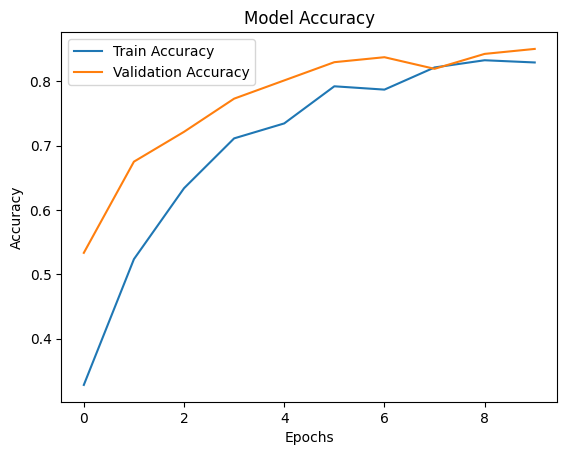

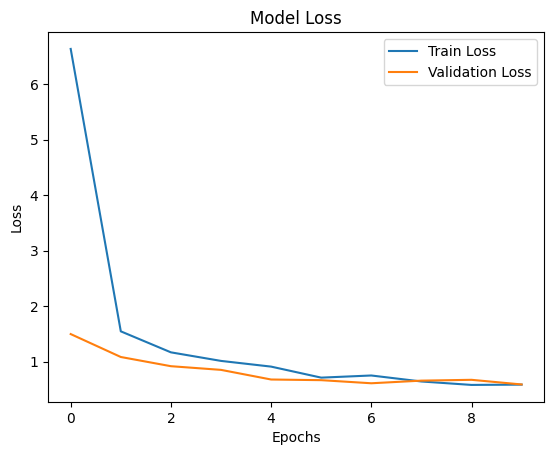

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.show()


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load an image
img_path = "/content/dataset/Animal Classification/dataset/Bear/Bear_10.jpg"
img = load_img(img_path, target_size=(224, 224))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
predictions = model.predict(img_array)
predicted_class = np.argmax(predictions)
class_indices = train_data.class_indices
class_names = list(class_indices.keys())
print(f"Predicted Class: {class_names[predicted_class]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted Class: Bear


In [ ]:
model.save("animal_classifier_model.h5")

In [ ]:
import tensorflow as tf

base_model.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
from google.colab import files

# Download the model file
files.download("animal_classifier_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# for Google Drive
model.save('/content/drive/My Drive/animal_classifier_model.h5')